In [400]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

In [401]:
# Data
x_train = pd.read_csv("../data/x_train_final.csv")
y_train = pd.read_csv("../data/y_train_final.csv")
x_test = pd.read_csv("../data/x_test_final.csv")

In [402]:
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [403]:
y_train

,Unnamed: 0,p0q0
0,0,-1.0
1,1,-1.0
2,2,-1.0
3,3,1.0
4,4,3.0
...,...,...
667259,667259,1.0
667260,667260,2.0
667261,667261,2.0
667262,667262,1.0


## Feature Engineering

In [ ]:
def fit_features(train_df: pd.DataFrame) -> dict:
    df = train_df.copy()
    df["date"] = pd.to_datetime(df["date"])

    cols_retard = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]

    mappings = {}

    # fréquence gare (OK)
    mappings["freq_gare"] = df["gare"].value_counts(normalize=True)

    # retard moyen par gare (OK)
    mappings["retard_moyen_gare"] = df.groupby("gare")[cols_retard].mean().mean(axis=1)


    # nombre moyen d'arrêts par gare
    mappings["nb_arrets_par_gare"] = df.groupby("gare")["arret"].nunique()

    return mappings

def transform_features(df: pd.DataFrame, mappings: dict) -> pd.DataFrame:
    df = df.copy()

    # Outliers
    df.loc[df["p0q3"] <= -500, "p0q3"] = (df["p0q2"] + df["p0q4"]) / 2
    df.loc[df["p0q4"] <= -500, "p0q4"] = (df["p0q2"] + df["p0q3"]) / 2

    # Date
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    # Encodage cyclique
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 5)

    # Frequency encoding gare
    df["encoded_gare"] = df["gare"].map(mappings["freq_gare"]).fillna(0)

    # Retard moyen par gare
    df["retard_moyen_gare"] = df["gare"].map(mappings["retard_moyen_gare"]).fillna(0)


    # Features retard train
    df["somme_retard_prev_trains"] = df["p2q0"] + df["p3q0"] + df["p4q0"]
    df["diff_retard_trains"] = df["p2q0"] - df["p4q0"]
    df["mean_retard_train"] = df[["p2q0","p3q0","p4q0"]].mean(axis=1)
    df["std_retard_train"] = df[["p2q0","p3q0","p4q0"]].std(axis=1)

    # Features retard gare
    df["somme_retard_prev_gares"] = df["p0q2"] + df["p0q3"] + df["p0q4"]
    df["diff_retard_gares"] = df["p0q2"] - df["p0q4"]
    df["mean_retard_gare"] = df[["p0q2","p0q3","p0q4"]].mean(axis=1)
    df["std_retard_gare"] = df[["p0q2","p0q3","p0q4"]].std(axis=1)
    
    df["retard_train_x_gare"] = df["mean_retard_train"] * df["encoded_gare"]
    
    # Nombre d'arrêts appris sur le train
    df["nb_arrets_gare"] = df["gare"].map(mappings["nb_arrets_par_gare"]).fillna(0)
    df["position_relative"] = df["arret"] / df["nb_arrets_gare"]
    df["retard_x_position"] = df["mean_retard_train"] * df["arret"]
    df["debut_trajet"] = (df["arret"] <= 12).astype(int)
    df["fin_trajet"] = (df["arret"] >= df["nb_arrets_gare"] - 3).astype(int)
    df["position_carre"] = df["arret"] ** 2

    # Drop colonnes inutiles
    cols_to_drop = ["Unnamed: 0.1", "Unnamed: 0", "date", "day_of_week", "month", "gare", "train"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

In [405]:
# Fit sur train, transform sur train et test
mappings = fit_features(x_train)
x_train_fe = transform_features(x_train, mappings)
x_test_fe = transform_features(x_test, mappings)

In [406]:
x_train_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,...,nb_arrets_gare,somme_retard_prev_trains,diff_retard_trains,mean_retard_train,std_retard_train,somme_retard_prev_gares,diff_retard_gares,mean_retard_gare,std_retard_gare,retard_train_x_gare
0,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,...,18,1.0,-1.0,0.333333,0.57735,-6.0,-1.0,-2.000000,1.000000,0.014855
1,9,0.0,0.0,0.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,...,18,0.0,0.0,0.000000,0.00000,2.0,0.0,0.666667,0.577350,0.000000
2,10,-1.0,0.0,0.0,-1.0,0.0,0.0,0.866025,-0.500000,0.000000,...,19,-1.0,-1.0,-0.333333,0.57735,-1.0,-1.0,-0.333333,0.577350,-0.013007
3,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,0.866025,-0.500000,0.000000,...,21,-2.0,-1.0,-0.666667,0.57735,0.0,2.0,0.000000,2.000000,-0.027817
4,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,0.866025,-0.500000,0.000000,...,22,-3.0,0.0,-1.000000,0.00000,4.0,-3.0,1.333333,2.081666,-0.043806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,-0.500000,0.866025,-0.951057,...,23,-7.0,6.0,-2.333333,3.21455,-3.0,1.0,-1.000000,1.000000,-0.026796
667260,23,0.0,0.0,-1.0,1.0,0.0,0.0,-0.500000,0.866025,-0.951057,...,24,-1.0,1.0,-0.333333,0.57735,1.0,1.0,0.333333,0.577350,-0.003876
667261,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,-0.500000,0.866025,-0.951057,...,23,1.0,1.0,0.333333,0.57735,-5.0,0.0,-1.666667,1.154701,0.004662
667262,26,2.0,2.0,1.0,0.0,0.0,1.0,-0.500000,0.866025,-0.951057,...,22,5.0,1.0,1.666667,0.57735,1.0,-1.0,0.333333,0.577350,0.002131


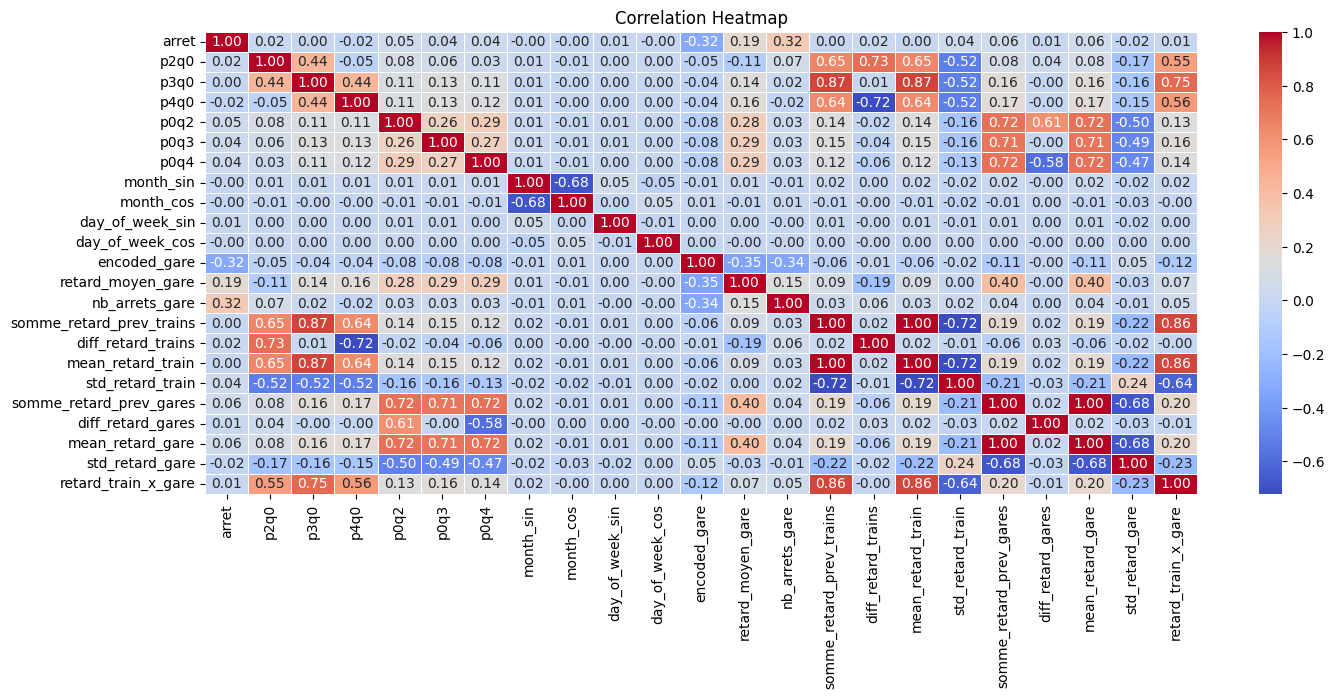

In [407]:
matrix = x_train_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [408]:
x_test_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,...,nb_arrets_gare,somme_retard_prev_trains,diff_retard_trains,mean_retard_train,std_retard_train,somme_retard_prev_gares,diff_retard_gares,mean_retard_gare,std_retard_gare,retard_train_x_gare
0,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0,-5.000000e-01,0.866025,0.000000,...,21,-2.0,2.0,-0.666667,1.154701,-10.0,0.0,-3.333333,1.154701,-0.027817
1,12,0.0,0.0,-1.0,1.0,-1.0,0.0,-5.000000e-01,0.866025,0.000000,...,21,-1.0,1.0,-0.333333,0.577350,0.0,1.0,0.000000,1.000000,-0.013909
2,12,0.0,1.0,-1.0,1.0,-1.0,1.0,-5.000000e-01,0.866025,0.000000,...,21,0.0,1.0,0.000000,1.000000,1.0,0.0,0.333333,1.154701,0.000000
3,12,0.0,0.0,-1.0,-1.0,0.0,-1.0,-5.000000e-01,0.866025,0.000000,...,21,-1.0,1.0,-0.333333,0.577350,-2.0,0.0,-0.666667,0.577350,-0.013909
4,12,1.0,-2.0,0.0,0.0,0.0,0.0,-5.000000e-01,0.866025,0.000000,...,20,-1.0,1.0,-0.333333,1.527525,0.0,0.0,0.000000,0.000000,-0.006138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20652,24,-1.0,-1.0,1.0,0.0,1.0,0.0,-2.449294e-16,1.000000,-0.951057,...,21,-1.0,-2.0,-0.333333,1.154701,1.0,0.0,0.333333,0.577350,-0.008580
20653,12,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.951057,...,21,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
20654,18,1.0,-2.0,0.0,-1.0,-1.0,-2.0,-2.449294e-16,1.000000,-0.951057,...,20,-1.0,1.0,-0.333333,1.527525,-4.0,1.0,-1.333333,0.577350,-0.010715
20655,24,-2.0,-2.0,1.0,0.0,0.0,1.0,-2.449294e-16,1.000000,-0.951057,...,21,-3.0,-3.0,-1.000000,1.732051,1.0,-1.0,0.333333,0.577350,-0.025739


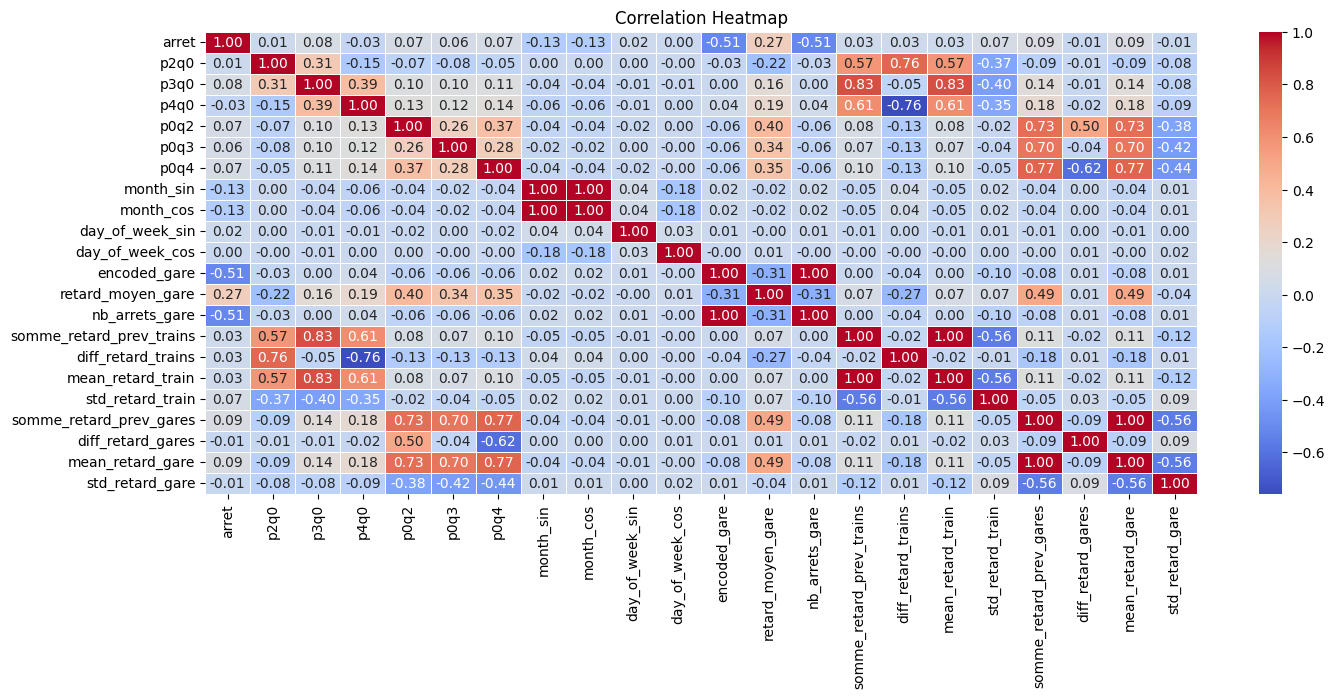

In [384]:
matrix = x_test_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Modeles

## LightGBM

In [409]:
import lightgbm as lgb

# Split temporel par mois
# Train months: [4, 5, 6, 9, 10, 11], Test months: [11, 12]
# Folds:
#   Fold 1: train=[4]         val=[5]
#   Fold 2: train=[4,5]       val=[6]
#   Fold 3: train=[4,5,6]     val=[9]
#   Fold 4: train=[4,5,6,9]   val=[10]
#   Fold 5: train=[4,5,6,9,10] val=[11]

x_train['date'] = pd.to_datetime(x_train['date'])
x_train['month'] = x_train['date'].dt.month

sorted_months = sorted(x_train['month'].unique())  # [4, 5, 6, 9, 10, 11]

# Créations des splits folds manuellement
custom_splits = []
for i in range(1, len(sorted_months)):
    train_months = sorted_months[:i]
    val_month = sorted_months[i]
    
    train_idx = x_train[x_train['month'].isin(train_months)].index.tolist()
    val_idx = x_train[x_train['month'] == val_month].index.tolist()
    
    custom_splits.append((train_idx, val_idx))
    print(f"Fold {i}: train months={train_months}, val month={val_month}, "
          f"train size={len(train_idx)}, val size={len(val_idx)}")



SEED = 42
lgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "max_depth": -1,
    "num_leaves": 64,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": SEED,
    "n_jobs": -1,
}


y = y_train.drop(columns=["Unnamed: 0"])["p0q0"]

oof_preds = np.full(len(x_train), np.nan)
test_preds = np.zeros(len(x_test))
fold_scores = []

n_folds = len(custom_splits)

print(f"\nEntraînement en {n_folds} folds temporels...")
print("─" * 60)

for fold, (train_idx, val_idx) in enumerate(custom_splits, 1):
    mappings = fit_features(x_train.iloc[train_idx])
    
    X_tr = transform_features(x_train.iloc[train_idx], mappings)
    X_val = transform_features(x_train.iloc[val_idx], mappings)
    X_test_fold = transform_features(x_test, mappings)
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)],
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test_fold) / n_folds
    
    val_pred = val_pred.round() # On arrondit pour avoir des minutes entières

    score = mean_absolute_error(y_val, val_pred)
    fold_scores.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
# OOF score (exclut le fold 1 qui n'a pas de prédiction)
valid_mask = ~np.isnan(oof_preds)
oof_score = mean_absolute_error(y[valid_mask], oof_preds[valid_mask])
print(f"  OOF global        | MAE = {oof_score:.4f}")
print(f"  Moyenne des folds | MAE = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Fold 1: train months=[np.int32(4)], val month=5, train size=97485, val size=115421
Fold 2: train months=[np.int32(4), np.int32(5)], val month=6, train size=212906, val size=164049
Fold 3: train months=[np.int32(4), np.int32(5), np.int32(6)], val month=9, train size=376955, val size=144367
Fold 4: train months=[np.int32(4), np.int32(5), np.int32(6), np.int32(9)], val month=10, train size=521322, val size=108257
Fold 5: train months=[np.int32(4), np.int32(5), np.int32(6), np.int32(9), np.int32(10)], val month=11, train size=629579, val size=37685

Entraînement en 5 folds temporels...
────────────────────────────────────────────────────────────
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[424]	valid_0's l1: 0.676609	valid_0's l2: 2.00372
  Fold 1 | MAE = 0.6299
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[348]	valid_0's l1: 0.951057	valid_0's l2: 3.45595
  Fold 2 | MAE = 0.9185
Traini

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

SEED = 42


xgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "max_depth": 7,               
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:absoluteerror", # Optimise directement la MAE 
    "eval_metric": "mae",
    "tree_method": "hist",         
    "random_state": SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 200,  
}


oof_preds_xgb = np.full(len(x_train), np.nan)
test_preds_xgb = np.zeros(len(x_test))
fold_scores_xgb = []

n_folds = len(custom_splits)

print(f"\nEntraînement XGBoost en {n_folds} folds temporels...")
print("─" * 60)

for fold, (train_idx, val_idx) in enumerate(custom_splits, 1):
    mappings = fit_features(x_train.iloc[train_idx])
    
    X_tr = transform_features(x_train.iloc[train_idx], mappings)
    X_val = transform_features(x_train.iloc[val_idx], mappings)
    X_test_fold = transform_features(x_test, mappings)
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Initialisation du modèle
    model = xgb.XGBRegressor(**xgb_params)
    
    # Entraînement
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=500 
    )

    val_pred = model.predict(X_val)
    oof_preds_xgb[val_idx] = val_pred
    
    test_preds_xgb += model.predict(X_test_fold) / n_folds

    score = mean_absolute_error(y_val, val_pred)
    fold_scores_xgb.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
# OOF score (exclut le fold 1 qui n'a pas de prédiction OOF)
valid_mask = ~np.isnan(oof_preds_xgb)
oof_score_xgb = mean_absolute_error(y[valid_mask], oof_preds_xgb[valid_mask])
print(f"  OOF global XGBoost        | MAE = {oof_score_xgb:.4f}")
print(f"  Moyenne des folds XGBoost | MAE = {np.mean(fold_scores_xgb):.4f} ± {np.std(fold_scores_xgb):.4f}")

## Optimisation Optuna

In [393]:
import optuna
import xgboost as xgb

SEED = 42

def objective(trial):
    params = {
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        "objective": "reg:absoluteerror",
        "eval_metric": "mae",
        "tree_method": "hist",
        "random_state": SEED,
        "n_jobs": -1,
        "early_stopping_rounds": 200,
    }

    X = x_train_fe
    y_target = y_train.drop(columns=["Unnamed: 0"])["p0q0"]

    oof_preds = np.full(len(X), np.nan)
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(custom_splits, 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_target.iloc[train_idx], y_target.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=0,
        )

        val_pred = model.predict(X_val)
        oof_preds[val_idx] = val_pred

        score = mean_absolute_error(y_val, val_pred)
        fold_scores.append(score)

        # Pruning : on coupe si le fold courant est déjà mauvais
        trial.report(score, fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    valid_mask = ~np.isnan(oof_preds)
    oof_mae = mean_absolute_error(y_target[valid_mask], oof_preds[valid_mask])
    return oof_mae

study = optuna.create_study(
    direction="minimize",
    study_name="xgb_mae_optim",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("\n" + "═" * 60)
print(f"  Meilleur OOF MAE : {study.best_value:.4f}")
print(f"  Meilleurs paramètres :")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")
print("═" * 60)

  0%|          | 0/10 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
  Meilleur OOF MAE : 0.7221
  Meilleurs paramètres :
    learning_rate: 0.015983207966804483
    max_depth: 10
    subsample: 0.7820192499651326
    colsample_bytree: 0.5814742369506802
    min_child_weight: 22
    reg_alpha: 0.18819347791534646
    reg_lambda: 8.1129220212159
    gamma: 5.229726899657575e-05
════════════════════════════════════════════════════════════


In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

SEED = 42

# Récupération des meilleurs paramètres trouvés par Optuna
best = study.best_params

xgb_params = {
    "n_estimators": 5000,
    "learning_rate": best["learning_rate"],
    "max_depth": best["max_depth"],
    "subsample": best["subsample"],
    "colsample_bytree": best["colsample_bytree"],
    "min_child_weight": best["min_child_weight"],
    "reg_alpha": best["reg_alpha"],
    "reg_lambda": best["reg_lambda"],
    "gamma": best["gamma"],
    "objective": "reg:absoluteerror",
    "eval_metric": "mae",
    "tree_method": "hist",
    "random_state": SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 200,
}

oof_preds_xgb = np.full(len(x_train), np.nan)
test_preds_xgb = np.zeros(len(x_test))
fold_scores_xgb = []

n_folds = len(custom_splits)

print(f"\nEntraînement XGBoost (params Optuna) en {n_folds} folds temporels...")
print(f"  Best OOF MAE from study: {study.best_value:.4f}")
print("─" * 60)

for fold, (train_idx, val_idx) in enumerate(custom_splits, 1):
    mappings = fit_features(x_train.iloc[train_idx])
    
    X_tr = transform_features(x_train.iloc[train_idx], mappings)
    X_val = transform_features(x_train.iloc[val_idx], mappings)
    X_test_fold = transform_features(x_test, mappings)
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBRegressor(**xgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=500
    )

    val_pred = model.predict(X_val)
    oof_preds_xgb[val_idx] = val_pred

    test_preds_xgb += model.predict(X_test_fold) / n_folds

    score = mean_absolute_error(y_val, val_pred)
    fold_scores_xgb.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
valid_mask = ~np.isnan(oof_preds_xgb)
oof_score_xgb = mean_absolute_error(y[valid_mask], oof_preds_xgb[valid_mask])
print(f"  OOF global XGBoost        | MAE = {oof_score_xgb:.4f}")
print(f"  Moyenne des folds XGBoost | MAE = {np.mean(fold_scores_xgb):.4f} ± {np.std(fold_scores_xgb):.4f}")

## Ré-entrainement avec paramètres optimaux

In [395]:
# arrondir les prédictions
test_preds_xgb = np.round(test_preds_xgb)

# soumission
submission = pd.DataFrame({
    'p0q0': test_preds_xgb
}, index=x_test.index)


oof_str = f"{oof_score_xgb:.4f}"

filename = f"../output/y_test_predictions_MAE_{oof_str}.csv"


print(f'Nombre de prédictions : {len(submission)}')
print(f'Valeurs manquantes    : {submission.isnull().sum().sum()}')
print(f'Min prédit            : {submission["p0q0"].min():.4f}')
print(f'Max prédit            : {submission["p0q0"].max():.4f}')
print(f'Moyenne prédite       : {submission["p0q0"].mean():.4f}')


submission.to_csv(filename)

print(f'\nFichier sauvegardé : {filename} ✓')
display(submission.head(10))

Nombre de prédictions : 20657
Valeurs manquantes    : 0
Min prédit            : -10.0000
Max prédit            : 3.0000
Moyenne prédite       : -0.0571

Fichier sauvegardé : ../output/y_test_predictions_MAE_0.7221.csv ✓


,p0q0
0,-1.0
1,0.0
2,0.0
3,0.0
4,-0.0
5,-0.0
6,-0.0
7,0.0
8,-0.0
9,-0.0
